# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt# importar librerías

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código 

In [3]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print()
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
print(usage.isna().sum())# Cantidad de valores nulos)
print()
print(usage.isna().mean())
print()
print()
print()
print(usage[['type', 'duration', 'length']])

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64



       type  duration  length
0      call      0.09     NaN
1      text       NaN    39.0
2      text       NaN    36.0
3      call      1.53     NaN
4      call      4.84     NaN
...     ...       ...     ...
39995  call      5.75     NaN
39996  call      3.06     NaN
39997  call      8.74     NaN
39998  text       NaN    43.0
39999  call      1.32     NaN

[40000 rows x 3 columns]


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

        - En el dataset users la columna city con 11,7% y la columna churn_date con 88,3%.
        - Y el dataset usage: date con 0.125% ; duration con 55,1% ; y length con 44.7%.
             
- Indica qué harías: ¿imputar, eliminar, ignorar?


        -  En Users, los valores faltantes en city se pueden investigar para imputar. Y en churn_date debido a la alta proporción, podría ignorarse o eliminarse; sin embargo, los nulos podrían indicar usuarios activos, por lo que primero debe validarse el significado de la columna.

  
        - En Usage, la columna date tiene muy pocos valores nulos (~0.1%), por lo que podrían eliminarse o imputarse fácilmente.
        La columna duration tiene ~55% de nulos y length ~45%; sin embargo, esto parece depender de la columna type. Los registros de tipo call usan duration, mientras que los de tipo text usan length, por lo que los valores nulos son esperados y no necesariamente representan errores.

  

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.select_dtypes(include='number').describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` contiene 4000 IDs diferentes y no parece tener sentinels.
- La columna `age` muestra edades hasta los 80 años. Pero el valor mínimo es claramente un outlier.

In [13]:
usage.select_dtypes(include='number').describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` no muestran señales evidentes de valores anómalos.
- Las columnas `duration` y `lenght` no presentan indicios evidentes de sentinels. No obstante, muestran dispersión en sus valores y máximos significativamente superiores a la media, lo que podría sugerir la presencia de algunos valores atípicos.

In [14]:
users[['city', 'plan']].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595



- La columna `city` contiene 7 categorías distintas. Presenta 469 valores faltantes (11.7% del total). La ciudad más frecuente es Bogotá, con 808 registros.
- La columna `plan` contiene 2 categorías y no presenta valores faltantes. El plan más frecuente es Basico, con 2595 registros (aproximadamente 65% de los usuarios). 


In [15]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` no presenta valores faltantes y contiene únicamente dos categorías: text y call. La categoría más frecuente es text, con 22.092 registros (aproximadamente el 55% del total), lo que indica una distribución relativamente equilibrada entre ambos tipos de uso.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
    - No se identificaron sentinels evidentes en las columnas analizadas de users y usage. Sin embargo, se encontraron valores faltantes en city, churn_date, duration y length. Además, duration y length presentan algunos valores máximos muy alejados del resto de los datos, lo que podría indicar la presencia de outliers.
- ¿Qué acción tomarías?
    - Investigar el significado de los valores faltantes antes de imputarlos o eliminarlos, especialmente en churn_date, duration y length, ya que podrían tener una explicación relacionada con el negocio. También revisaría los posibles outliers mediante gráficos o análisis adicionales para determinar si son errores o casos válidos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, hay registros de los años 2022, 2023 y 2024, además de 40 registros con año 2026, los cuales se consideran inconsistentes al estar fuera del rango esperado y deberían revisarse o corregirse.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, todas las fechas válidas corresponden al año 2024, por lo que no se detectan años fuera de rango; únicamente existen algunos valores faltantes previamente identificados.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  

- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
    - Sí. En la columna reg_date se encontraron 40 registros del año 2026, que están fuera del rango esperado ya que el dataset solo contiene información hasta 2024. En la tabla usage no se encontraron años fuera de rango.
- ¿Qué harías con ellas?
    -  Revisaría los registros de 2026 para confirmar si son errores de captura. Si no es posible corregirlos, los marcaría como inválidos o los excluiría del análisis.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].isna().sum()

565

In [22]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts().sort_index()


2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Los valores nulos en duration y length dependen directamente de la columna type. Los registros de tipo call contienen información de duración pero no de longitud, mientras que los registros de tipo text contienen información de longitud pero no de duración. Por lo tanto, estos nulos son esperados y representan información no aplicable, por lo que se mantendrán sin imputar para evitar introducir datos incorrectos en el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.
  

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg.columns = [
    "user_id",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

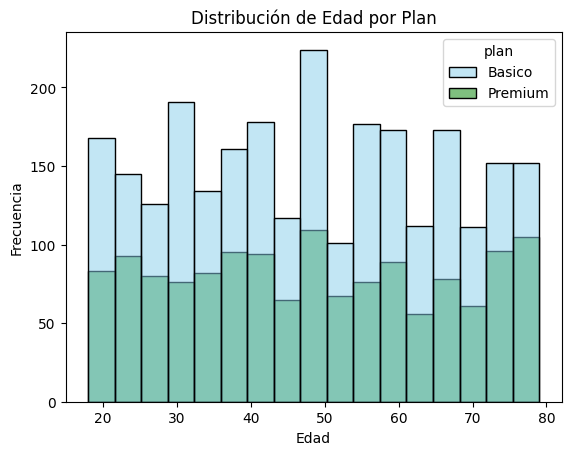

In [28]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución de edad: La mayor concentración de usuarios se encuentra alrededor de los 50 años, seguida por un grupo cercano a los 30 años. También se observan concentraciones menores en edades como 20, 40, 55, 60 y 65 años. En la mayoría de los grupos de edad, los usuarios de los planes Básico y Premium presentan proporciones similares, aunque en algunos segmentos específicos se observa mayor presencia de usuarios Premium. La distribución no muestra un sesgo marcado hacia edades altas o bajas.

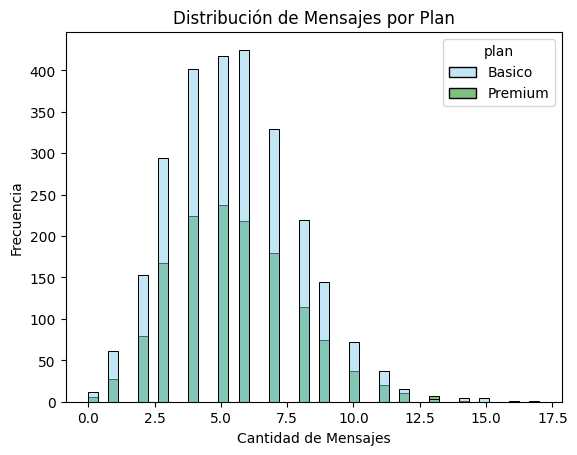

In [29]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución de mensajes: La mayor parte de los usuarios envía una cantidad baja o moderada de mensajes. La frecuencia aumenta gradualmente desde los valores más bajos hasta alcanzar un pico entre 4 y 5.5 mensajes, y luego disminuye progresivamente. A partir de aproximadamente 12.5 mensajes la frecuencia es muy reducida, por lo que existen pocos usuarios con una actividad de mensajería elevada. La distribución de los planes Básico y Premium es muy similar en casi todos los rangos, sin diferencias claras entre ambos grupos.

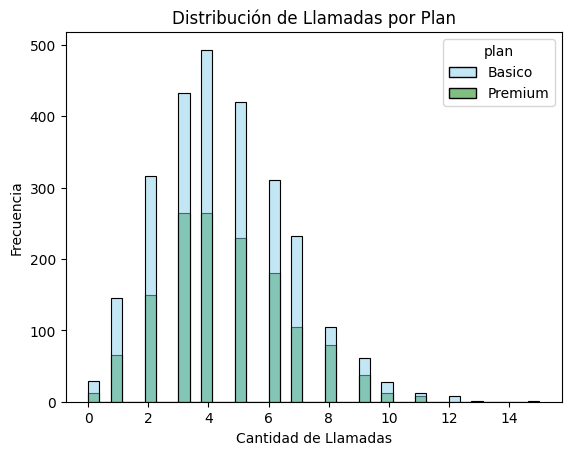

In [30]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución de llamadas: La frecuencia de llamadas aumenta gradualmente desde los valores más bajos hasta alcanzar un máximo alrededor de 4 llamadas. A partir de este punto, la frecuencia disminuye progresivamente entre 5 y 12 llamadas, mientras que los usuarios con más de 12 llamadas son poco frecuentes. Se observa una ligera mayor presencia de usuarios Premium en algunos rangos específicos (por ejemplo, 3, 4, 6, 9 y 11 llamadas), aunque en términos generales ambos planes presentan una distribución bastante similar.

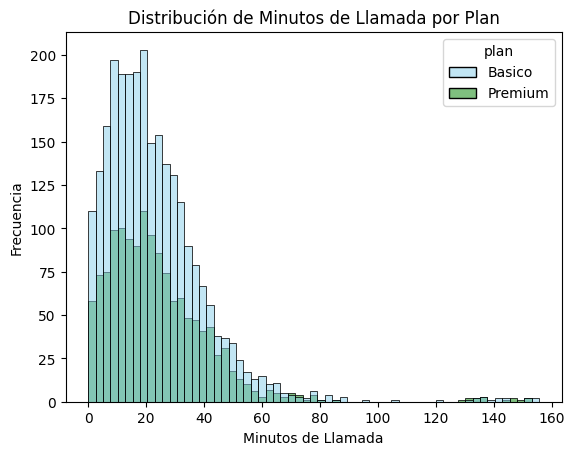

In [31]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución de minutos de llamada: La frecuencia de usuarios aumenta ligeramente entre 0 y 10 minutos, alcanzando su punto máximo entre 10 y 20 minutos de llamadas acumuladas. A partir de este rango, la frecuencia disminuye progresivamente hasta aproximadamente los 60 minutos. Entre 60 y 80 minutos aún se observan algunos usuarios, mientras que por encima de 80 minutos la presencia es muy reducida, aunque existe un pequeño grupo de usuarios con consumos excepcionalmente altos. La distribución entre los planes Básico y Premium es similar en la mayoría de los rangos, sin diferencias significativas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

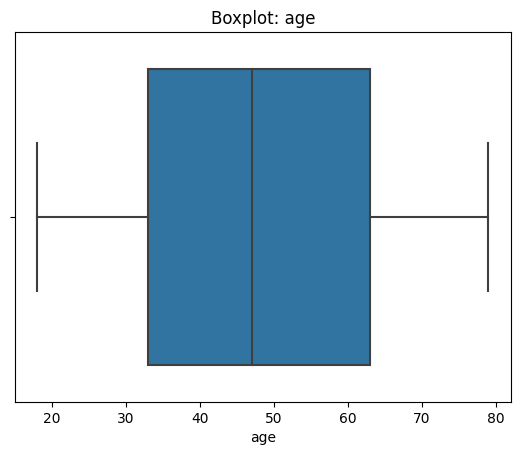

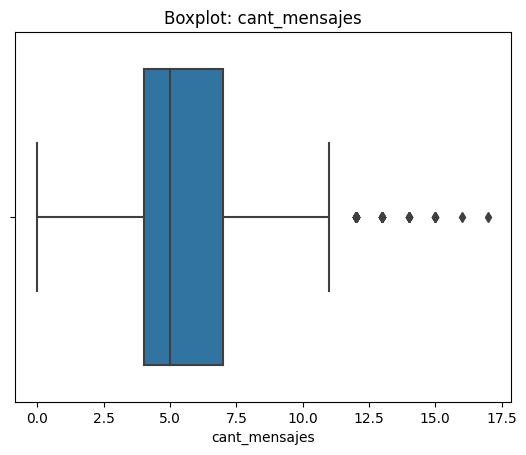

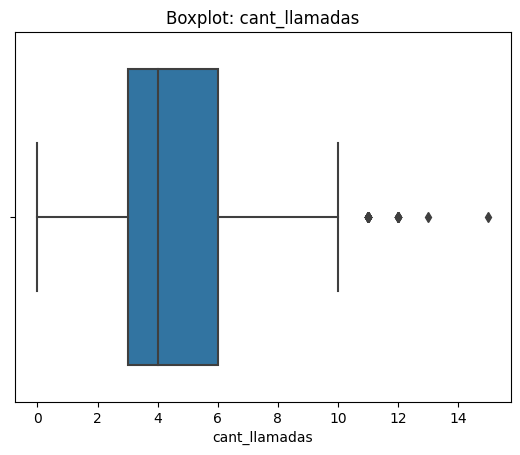

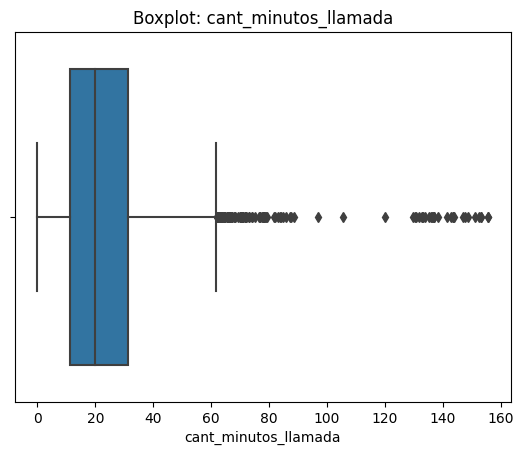

In [32]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers. Las edades se encuentran dentro de un rango razonable (18–80 años), por lo que no es necesario aplicar tratamiento adicional ni calcular límites IQR para esta variable.
- cant_mensajes: Presenta outliers superiores. La mayoría de los usuarios envía entre 0 y 11 mensajes, pero existe un pequeño grupo que alcanza valores más altos (entre aproximadamente 12.5 y 17.5 mensajes). Estos valores parecen corresponder a usuarios con una actividad de mensajería más intensa.
- cant_llamadas: Presenta outliers superiores. La mayoría de los usuarios realiza entre 0 y 10 llamadas, con una mediana cercana a 4 llamadas. Sin embargo, existe un pequeño grupo de usuarios que alcanza entre 11 y 15 llamadas, considerados valores atípicos dentro de la distribución.
- cant_minutos_llamada: Presenta una cantidad considerable de outliers superiores. La mayoría de los usuarios acumula entre 0 y 60 minutos de llamadas, mientras que algunos usuarios alcanzan valores mucho más altos, llegando aproximadamente a 160 minutos. Esto refleja una fuerte variabilidad en el tiempo de uso del servicio.

In [35]:
# Calcular límites con el método IQR
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    upper = Q3 + 1.5 * IQR

    print(f'{col}')
    print(f'Límite superior: {upper}')
    print(f'Máximo: {user_profile[col].max()}')
    print()



cant_mensajes
Límite superior: 11.5
Máximo: 17.0

cant_llamadas
Límite superior: 10.5
Máximo: 15.0

cant_minutos_llamada
Límite superior: 61.8575
Máximo: 155.69



In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
    - Se mantendrán los outliers, ya que representan usuarios con una actividad de mensajería más alta de lo habitual y no parecen corresponder a errores de captura.
- cant_llamadas: mantener o no outliers, porqué?
    - Se mantendrán los outliers, ya que reflejan usuarios que realizan más llamadas que el promedio. Los valores observados son razonables y consistentes con el comportamiento esperado de algunos clientes. 
- cant_minutos_llamada: mantener o no outliers, porqué?
    - Se mantendrán los outliers, ya que los valores elevados de minutos de llamada pueden corresponder a usuarios con un uso intensivo del servicio. No se observan indicios de errores de captura ni valores imposibles.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [38]:
# Crear columna grupo_uso
def segmentar_usuario(row):

    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'

    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'

    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(segmentar_usuario, axis=1)

In [39]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso



### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos


In [40]:
# Crear columna grupo_edad
def segmentar_edad(row):

    edad = row['age']

    if edad < 30:
        return 'Joven'

    elif edad < 60:
        return 'Adulto'

    else:
        return 'Adulto Mayor'
user_profile['grupo_edad'] = user_profile.apply(segmentar_edad, axis=1)

In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

<AxesSubplot:xlabel='grupo_uso', ylabel='count'>

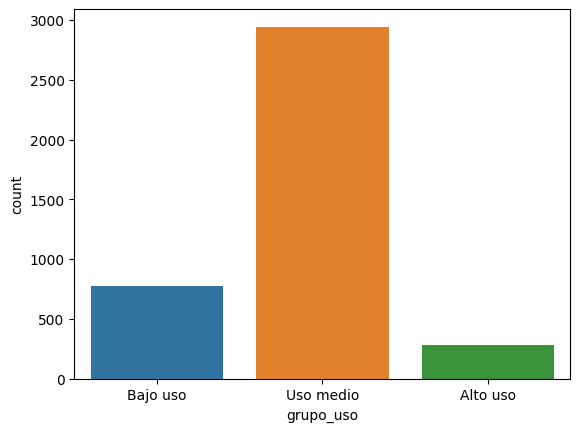

In [46]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso']
)

<AxesSubplot:xlabel='grupo_edad', ylabel='count'>

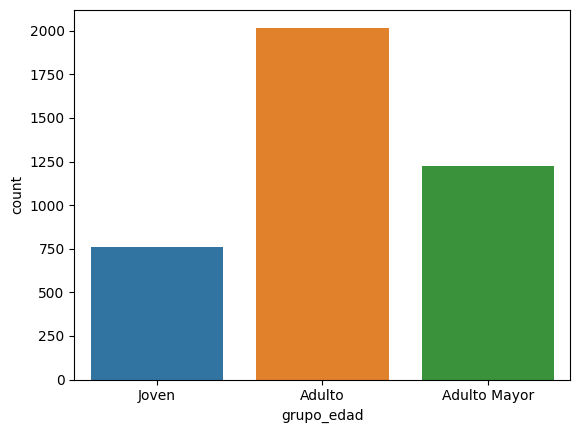

In [47]:
# Visualización de los segmentos por edad

sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor']
)


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- La columna age contenía valores sentinel (-999), los cuales representaban edades inválidas y fueron reemplazados por la mediana para preservar la distribución de los datos.
- La columna city contenía el valor sentinel "?", que fue convertido a valores nulos (NA) para su posterior tratamiento.
- La columna reg_date presentaba 40 registros con fechas futuras (2026), equivalentes al 1% de los usuarios aproximadamente, por lo que fueron marcadas como nulas.
- Las columnas duration y length contenían una gran proporción de valores nulos. Sin embargo, se confirmó que estos dependían del tipo de interacción (call o text), por lo que se consideraron valores MAR (Missing At Random) y se mantuvieron sin imputar.


🔍 **Segmentos por Edad**
- Se identificaron tres segmentos: Jóvenes (<30 años), Adultos (30-59 años) y Adultos Mayores (60+ años).
- El grupo predominante corresponde a los Adultos, lo que indica que la mayor parte de la base de clientes se concentra en edades medias. 


📊 **Segmentos por Nivel de Uso**
- Se clasificó a los usuarios en Bajo uso, Uso medio y Alto uso según su cantidad de llamadas y mensajes.
- El segmento más numeroso fue el de Uso medio, indicando que la mayoría de los clientes mantiene una actividad moderada dentro de la plataforma.


➡️ Esto sugiere que la base de clientes de ConnectaTel está compuesta principalmente por usuarios adultos con patrones de uso moderados. Además, no se observaron diferencias extremas entre los distintos grupos de usuarios, lo que indica un comportamiento relativamente estable de la cartera de clientes.


💡 **Recomendaciones**
- Diseñar planes o beneficios específicos para usuarios de Alto uso, especialmente aquellos con una alta cantidad de minutos de llamada, ya que representan clientes con un consumo superior al promedio.
- Mantener una oferta equilibrada para el segmento de Uso medio, dado que constituye la mayor parte de la base de clientes.
- Analizar en mayor profundidad a los usuarios con consumos extremos para identificar oportunidades de fidelización o planes premium adaptados a sus necesidades.
- Implementar validaciones en los procesos de captura de datos para evitar edades sentinel y fechas futuras en futuros registros.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`